In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

pd.options.display.float_format = '{:,.2f}'.format

data = pd.read_csv('boston.csv', index_col = 0)

### The House Price Dataset (Boston)

---

**Characteristics:**  

Number of Instances: 506 
Number of Attributes: 13 numeric/categorical predictive. The Median Value (attribute 14) is the target.

Attribute Information (in order):
1. CRIM - per capita crime rate by town
2. ZN - proportion of residential land zoned for lots over 25,000 sq.ft.
3. INDUS - proportion of non-retail business acres per town
4. CHAS - Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
5. NOX - nitric oxides concentration (parts per 10 million)
6. RM - average number of rooms per dwelling
7. AGE - proportion of owner-occupied units built prior to 1940
8. DIS - weighted distances to five Boston employment centres
9. RAD - index of accessibility to radial highways
10. TAX - full-value property-tax rate per $10,000
11. PTRATIO - pupil-teacher ratio by town
12. B - 1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
13. LSTAT - % lower status of the population
14. PRICE - Median value of owner-occupied homes in $1000's

Missing Attribute Values: None

Creator: Harrison, D. and Rubinfeld, D.L.

The [original research paper](https://deepblue.lib.umich.edu/bitstream/handle/2027.42/22636/0000186.pdf?sequence=1&isAllowed=y).

In [2]:
print(f'Shape : {data.shape}')
data.head()

Shape : (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.01,18.00,2.31,0.00,0.54,6.58,65.20,4.09,1.00,296.00,15.30,396.90,4.98,24.00
1,0.03,0.00,7.07,0.00,0.47,6.42,78.90,4.97,2.00,242.00,17.80,396.90,9.14,21.60
2,0.03,0.00,7.07,0.00,0.47,7.18,61.10,4.97,2.00,242.00,17.80,392.83,4.03,34.70
3,0.03,0.00,2.18,0.00,0.46,7.00,45.80,6.06,3.00,222.00,18.70,394.63,2.94,33.40
4,0.07,0.00,2.18,0.00,0.46,7.15,54.20,6.06,3.00,222.00,18.70,396.90,5.33,36.20


In [3]:
print(f'Columns : {data.columns}')
data.tail()

Columns : Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'PRICE'],
      dtype='object')


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
501,0.06,0.00,11.93,0.00,0.57,6.59,69.10,2.48,1.00,273.00,21.00,391.99,9.67,22.40
502,0.05,0.00,11.93,0.00,0.57,6.12,76.70,2.29,1.00,273.00,21.00,396.90,9.08,20.60
503,0.06,0.00,11.93,0.00,0.57,6.98,91.00,2.17,1.00,273.00,21.00,396.90,5.64,23.90
504,0.11,0.00,11.93,0.00,0.57,6.79,89.30,2.39,1.00,273.00,21.00,393.45,6.48,22.00
505,0.05,0.00,11.93,0.00,0.57,6.03,80.80,2.50,1.00,273.00,21.00,396.90,7.88,11.90


In [4]:
print(f'NaN : {data.isna().values.any()}')
print(f'Duplicates : {data.duplicated().values.any()}')
data.describe()

NaN : False
Duplicates : False


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.39,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.23,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


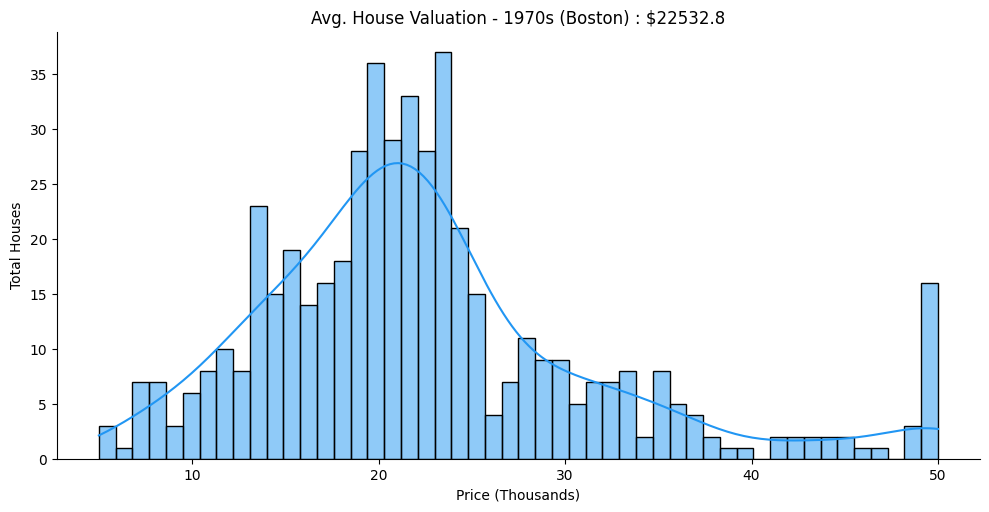

In [5]:
sns.displot(data['PRICE'], bins = 50, aspect = 2, kde = True, color = '#2196f3')

plt.title(f'Avg. House Valuation - 1970s (Boston) : ${(1000 * data.PRICE.mean()):.6}')

plt.xlabel('Price (Thousands)')
plt.ylabel('Total Houses')

plt.show()

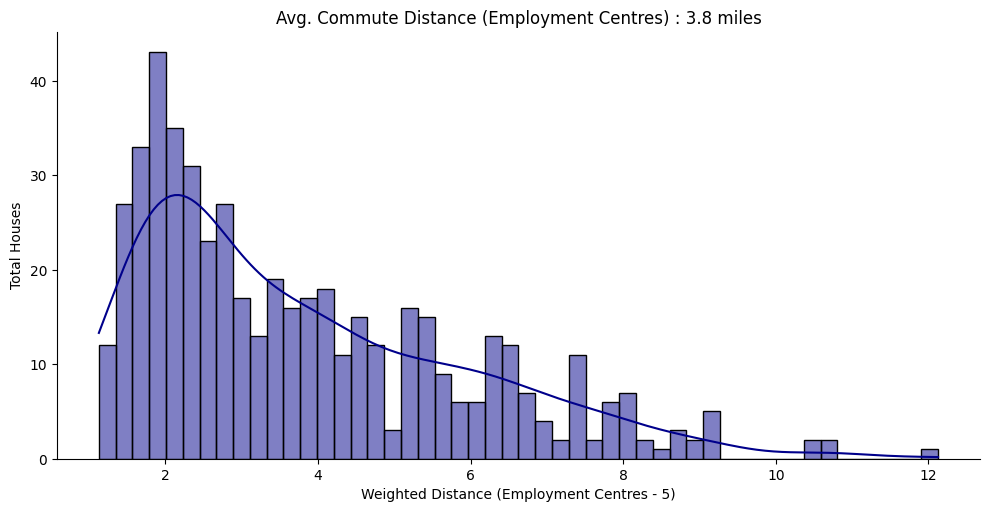

In [6]:
sns.displot(data.DIS, bins = 50, aspect = 2, kde = True, color = 'darkblue')

plt.title(f'Avg. Commute Distance (Employment Centres) : {(data.DIS.mean()):.2} miles')

plt.xlabel('Weighted Distance (Employment Centres - 5)')
plt.ylabel('Total Houses')

plt.show()

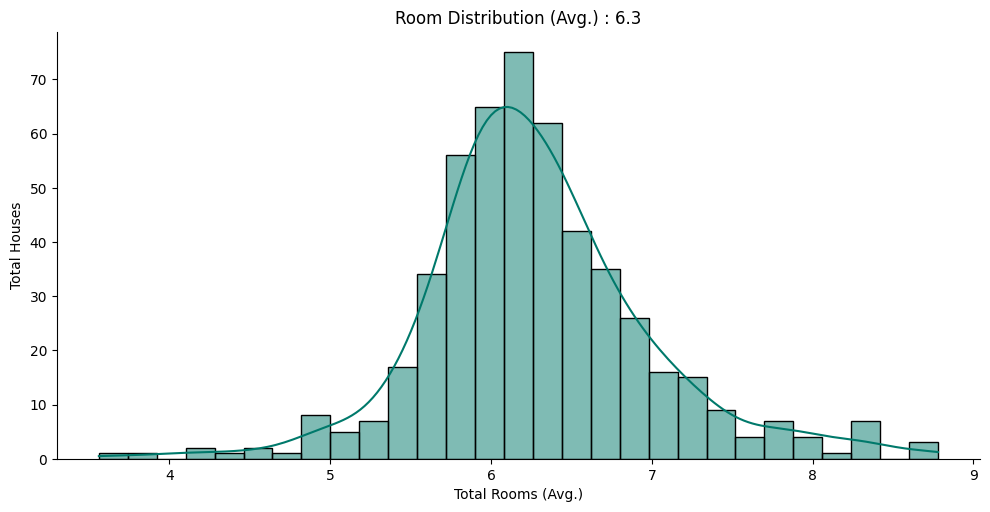

In [7]:
sns.displot(data.RM, aspect = 2, kde = True, color = '#00796b')

plt.title(f'Room Distribution (Avg.) : {(data.RM.mean()):.2}')

plt.xlabel('Total Rooms (Avg.)')
plt.ylabel('Total Houses')

plt.show()

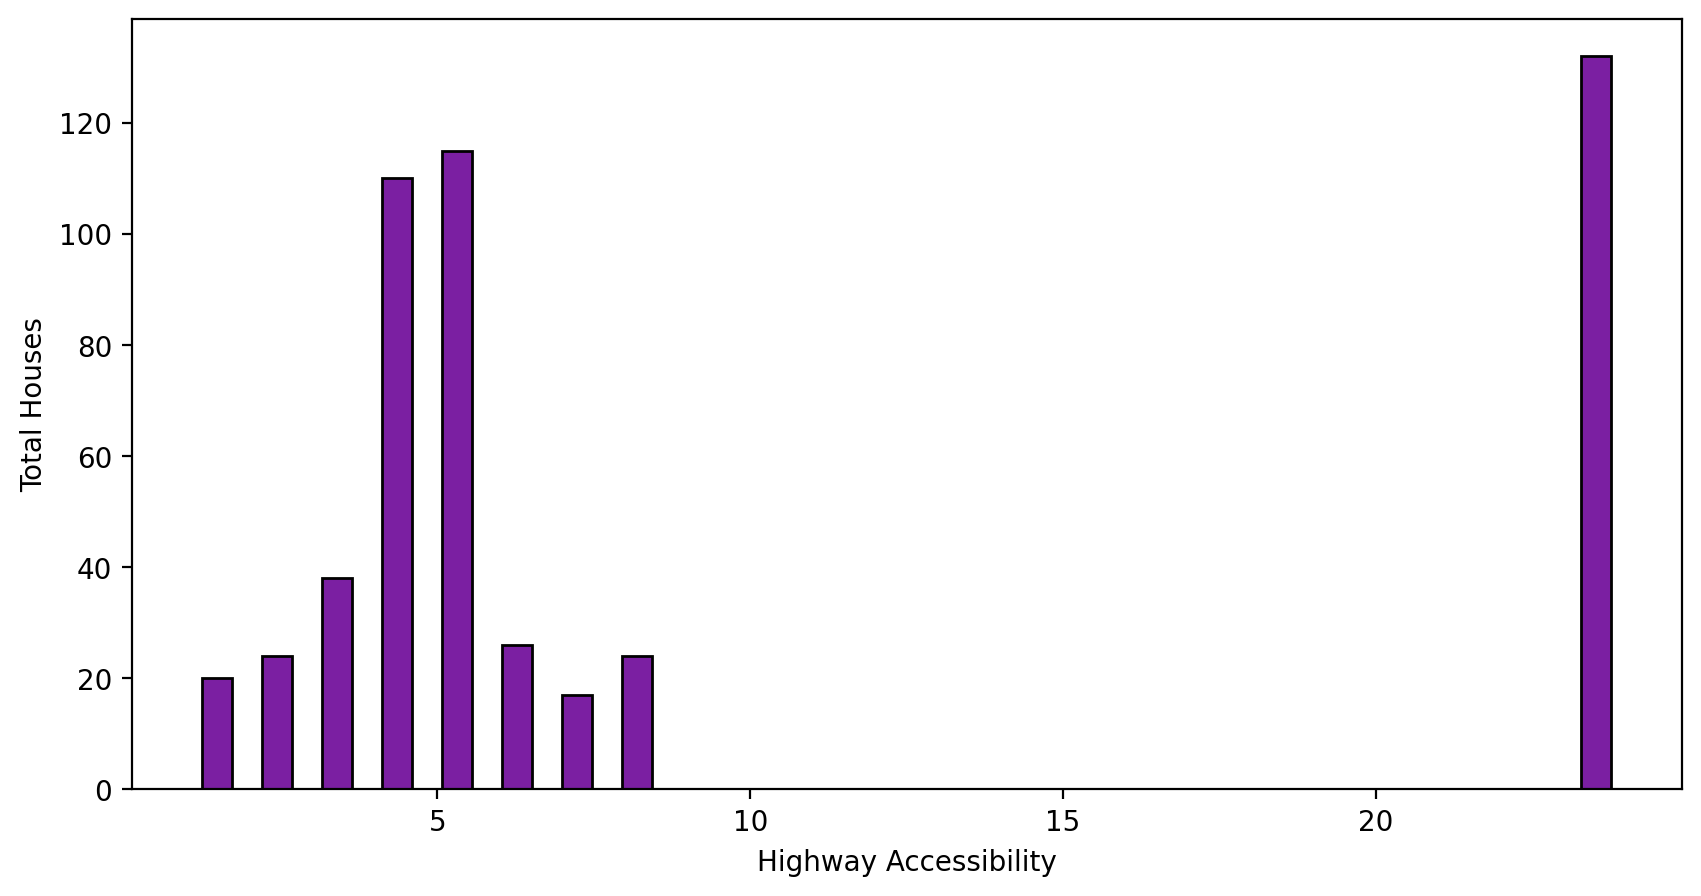

In [8]:
plt.figure(figsize = (10, 5), dpi = 200)

plt.hist(data['RAD'], bins = 24, ec = 'black', color = '#7b1fa2', rwidth = 0.5)

plt.xlabel('Highway Accessibility')
plt.ylabel('Total Houses')

plt.show()

In [9]:
river_access = data['CHAS'].value_counts()

bar = px.bar(x = ['NO', 'YES'], y = river_access.values, color = river_access.values, color_continuous_scale = px.colors.sequential.haline, title = 'House by Chales River')

bar.update_layout(xaxis_title = 'Property Location near Charles River?', yaxis_title = 'Total Houses', coloraxis_showscale = False)

bar.show()

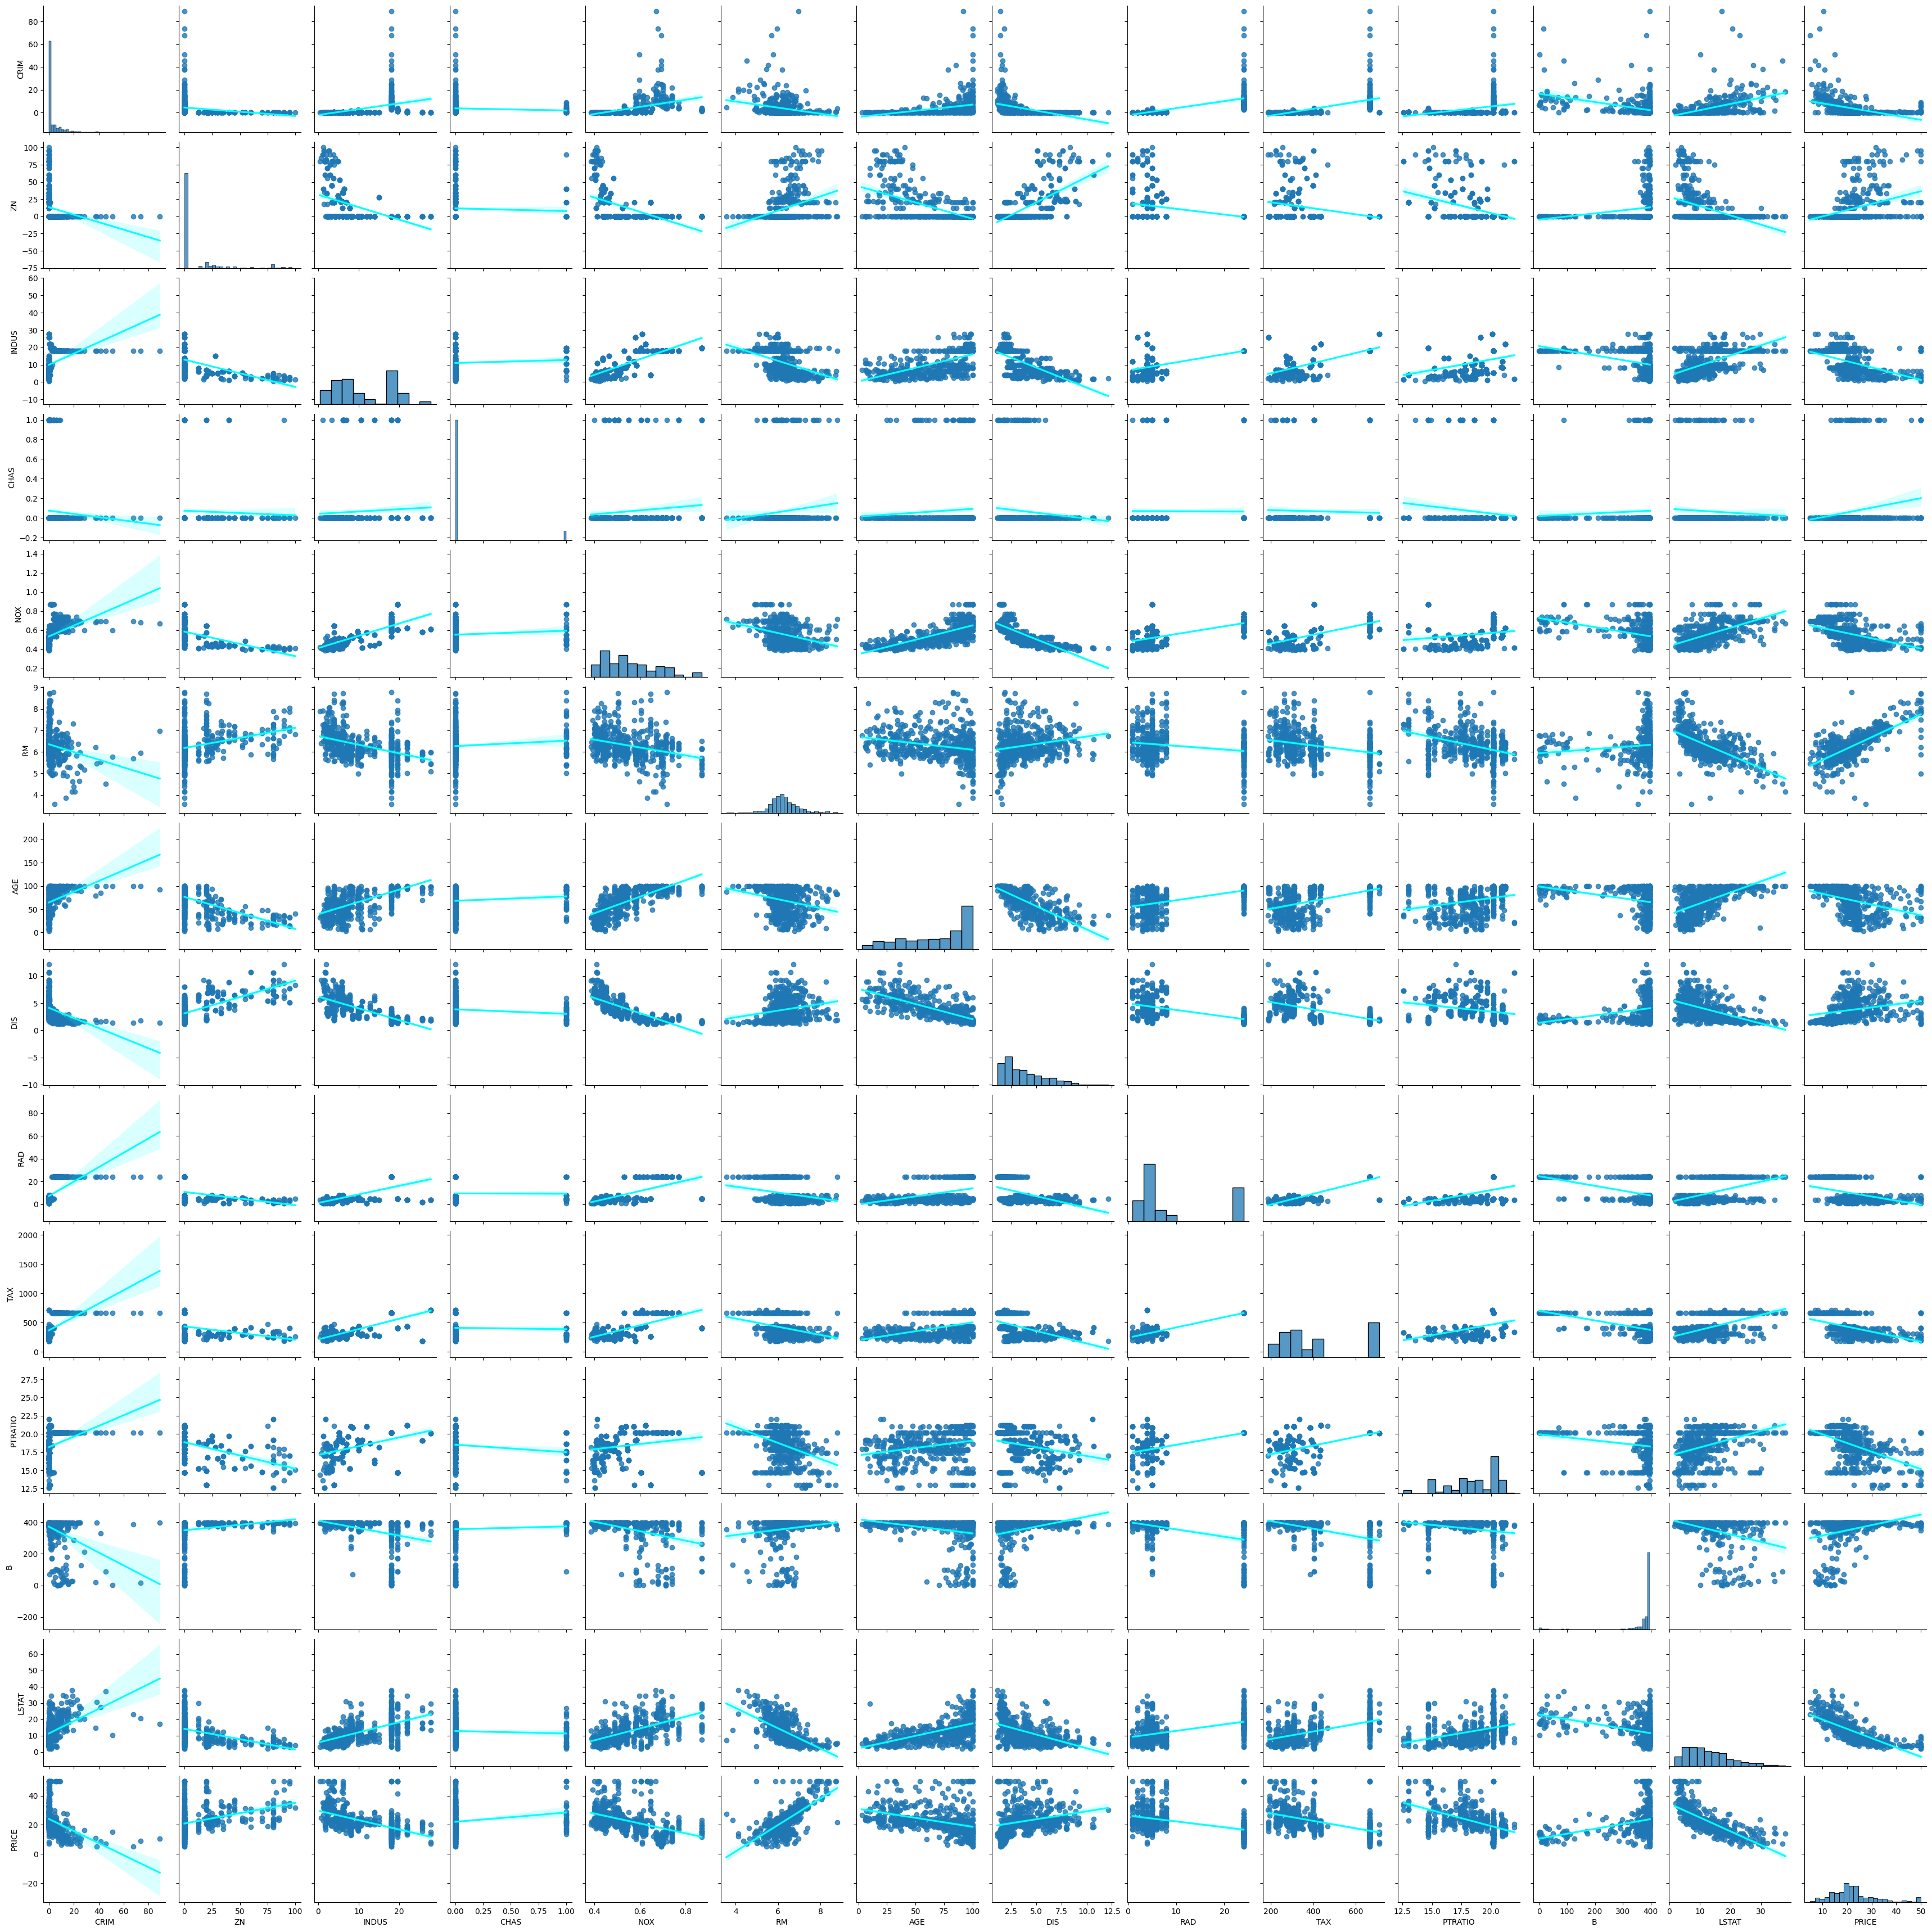

In [10]:
sns.pairplot(data, kind = 'reg', plot_kws = {'line_kws': {'color': 'cyan'}})

plt.show()

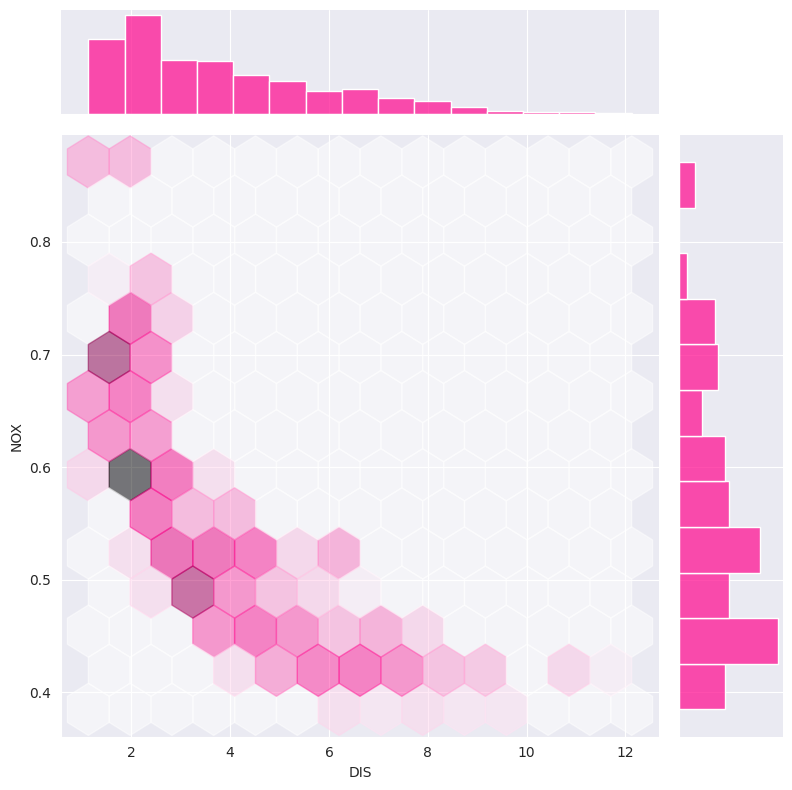

In [11]:
with sns.axes_style('darkgrid'):
    sns.jointplot(x = data['DIS'], y = data['NOX'], height = 8, kind = 'hex', color = 'deeppink', joint_kws = {'alpha': 0.5})

plt.show()

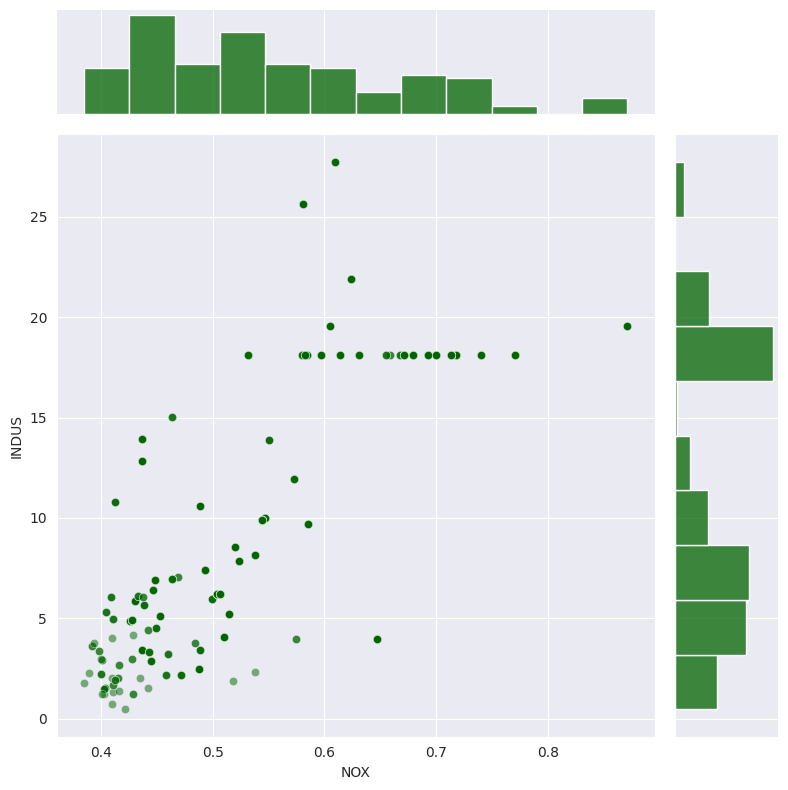

In [12]:
with sns.axes_style('darkgrid'):
    sns.jointplot(x = data.NOX, y = data.INDUS, height = 8, kind = 'scatter', color = 'darkgreen', joint_kws = {'alpha': 0.5})

plt.show()

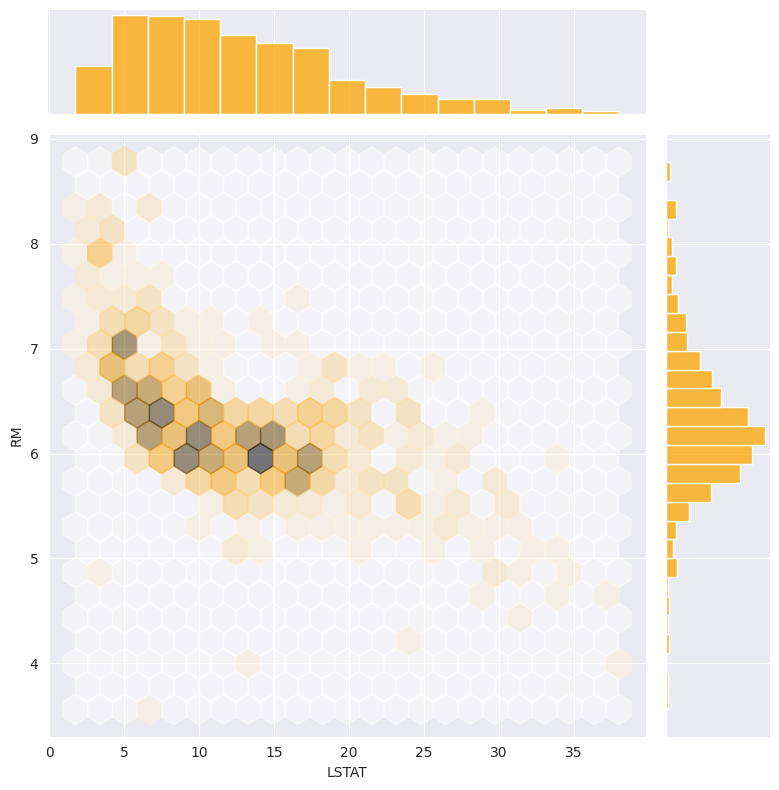

In [13]:
with sns.axes_style('darkgrid'):
    sns.jointplot(x = data['LSTAT'], y = data['RM'], height = 8, kind = 'hex', color = 'orange', joint_kws = {'alpha': 0.5})

plt.show()

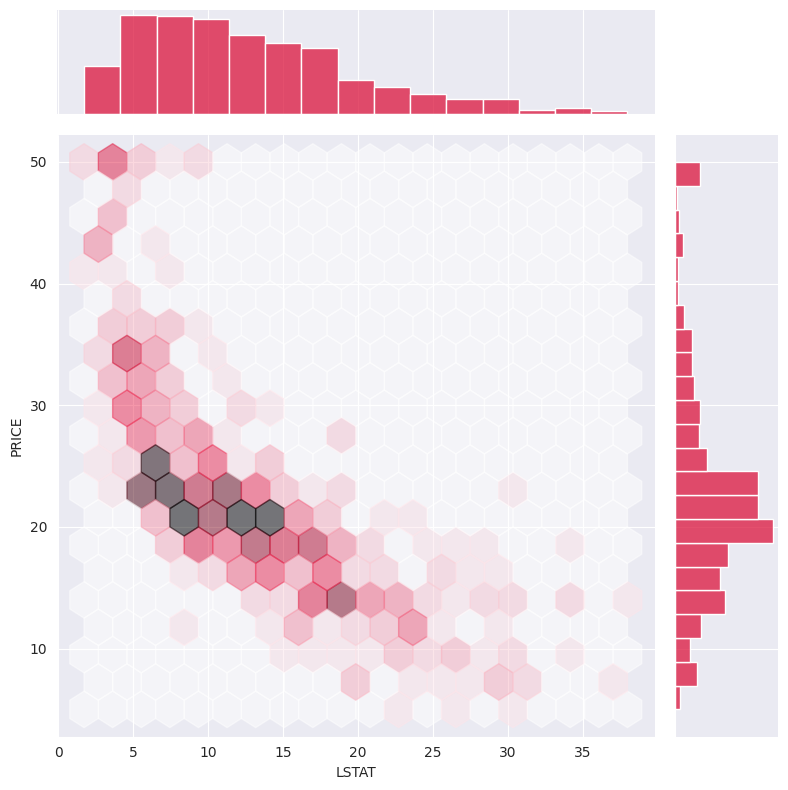

In [14]:
with sns.axes_style('darkgrid'):
    sns.jointplot(x = data.LSTAT, y = data.PRICE, kind = 'hex', height = 8, color = 'crimson', joint_kws = {'alpha': 0.5})

plt.show()

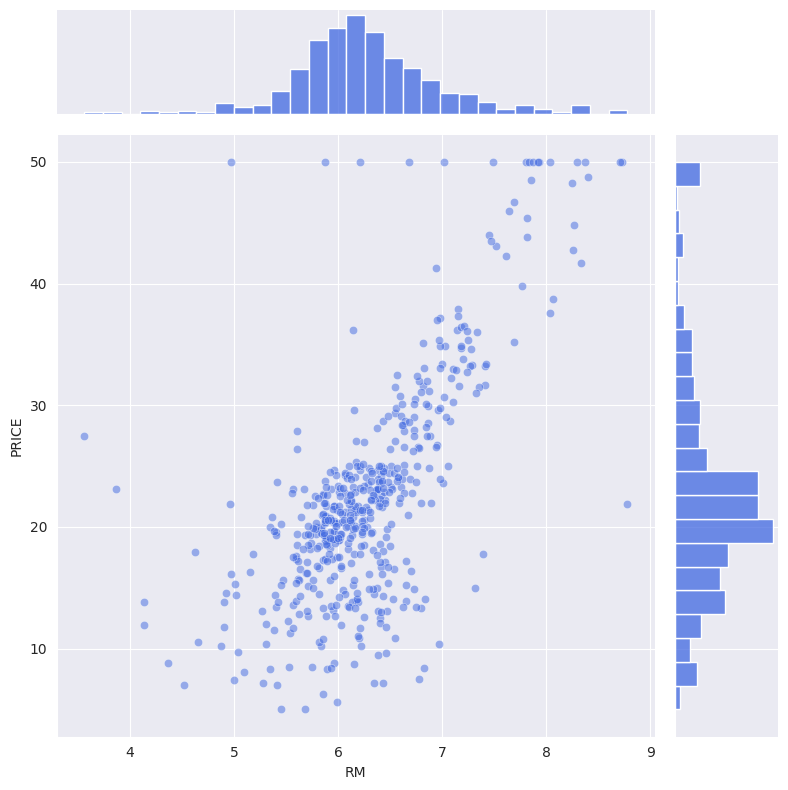

In [15]:
with sns.axes_style('darkgrid'):
    sns.jointplot(x = data.RM, y = data.PRICE, kind = 'scatter', height = 8, color = 'royalblue', joint_kws = {'alpha': 0.5})

plt.show()

In [16]:
target = data['PRICE']
features = data.drop('PRICE', axis = 1)

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size = 0.2, random_state = 10)

train_pct = 100 * len(x_train) / len(features)
print(f'Training Data (%) : {train_pct:.3}')

test_pct = 100 * x_test.shape[0] / features.shape[0]
print(f'Test Data (%) : {test_pct:.3}')

Training Data (%) : 79.8
Test Data (%) : 20.2


# Multivariable Regression

**Linear Regression form:**

$$ PR \hat ICE = \theta _0 + \theta _1 RM + \theta _2 NOX + \theta _3 DIS + \theta _4 CHAS ... + \theta _{13} LSTAT$$

In [17]:
regr = LinearRegression()

regr.fit(x_train, y_train)
rsquared = regr.score(x_train, y_train)

print(f'Training Data (r²) : {rsquared:.2}')

Training Data (r²) : 0.75


In [18]:
regr_coeff = pd.DataFrame(data = regr.coef_, index = x_train.columns, columns = ['Coefficient'])
regr_coeff

,Coefficient
CRIM,-0.13
ZN,0.06
INDUS,-0.01
CHAS,1.97
NOX,-16.27
RM,3.11
AGE,0.02
DIS,-1.48
RAD,0.30
TAX,-0.01


In [19]:
premium =  regr_coeff.loc['RM'].values[0] * 1000
print(f'Premium price for an extra room : ${premium:.5}')

Premium price for an extra room : $3108.5


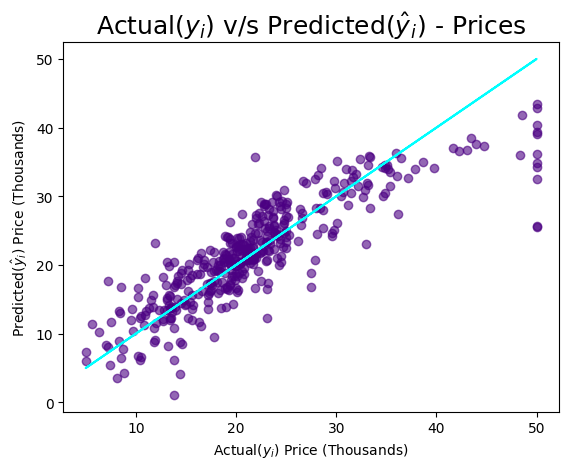

In [20]:
predicted_vals = regr.predict(x_train)

plt.figure(dpi = 100)
plt.scatter(x = y_train, y = predicted_vals, c = 'indigo', alpha = 0.6)
plt.plot(y_train, y_train, color = 'cyan')

plt.title(r'Actual($y _i$) v/s Predicted($\hat y_i$) - Prices', fontsize = 18)
plt.xlabel(r'Actual($y _i$) Price (Thousands)')
plt.ylabel(r'Predicted($\hat y_i$) Price (Thousands)')

plt.show()

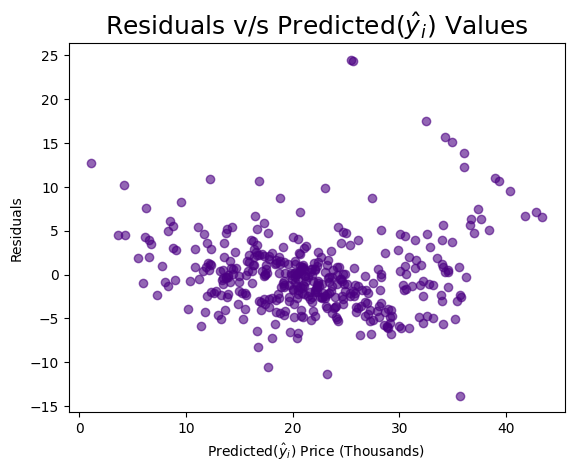

In [21]:
residuals = (y_train - predicted_vals)

plt.figure(dpi = 100)
plt.scatter(x = predicted_vals, y = residuals, c = 'indigo', alpha = 0.6)

plt.title(r'Residuals v/s Predicted($\hat y_i$) Values', fontsize = 18)

plt.ylabel(r'Residuals')
plt.xlabel(r'Predicted($\hat y_i$) Price (Thousands)')

plt.show()

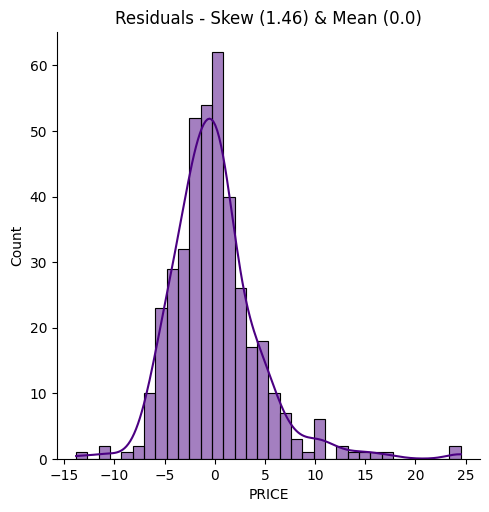

In [22]:
residual_mean = abs(round(residuals.mean(), 2))
residual_skew = round(residuals.skew(), 2)

sns.displot(residuals, kde = True, color = 'indigo')
plt.title(f'Residuals - Skew ({residual_skew}) & Mean ({residual_mean})')

plt.show()

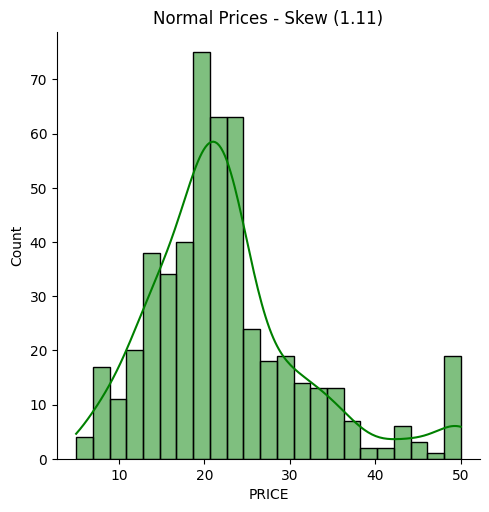

In [23]:
tgt_skew = data['PRICE'].skew()

sns.displot(data['PRICE'], kde = 'kde', color = 'green')
plt.title(f'Normal Prices - Skew ({tgt_skew:.3})')

plt.show()

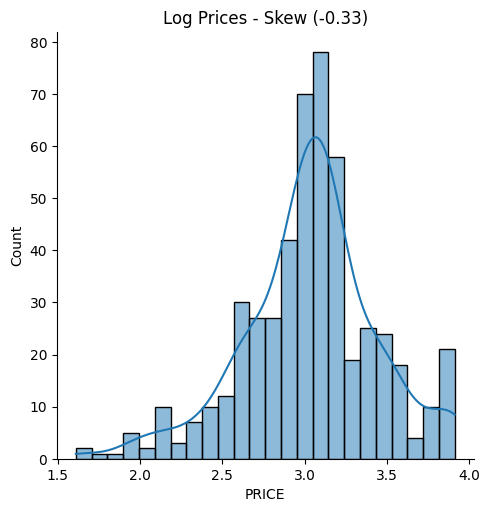

In [24]:
y_log = np.log(data.PRICE)

sns.displot(y_log, kde = True)
plt.title(f'Log Prices - Skew ({y_log.skew():.3})')

plt.show()

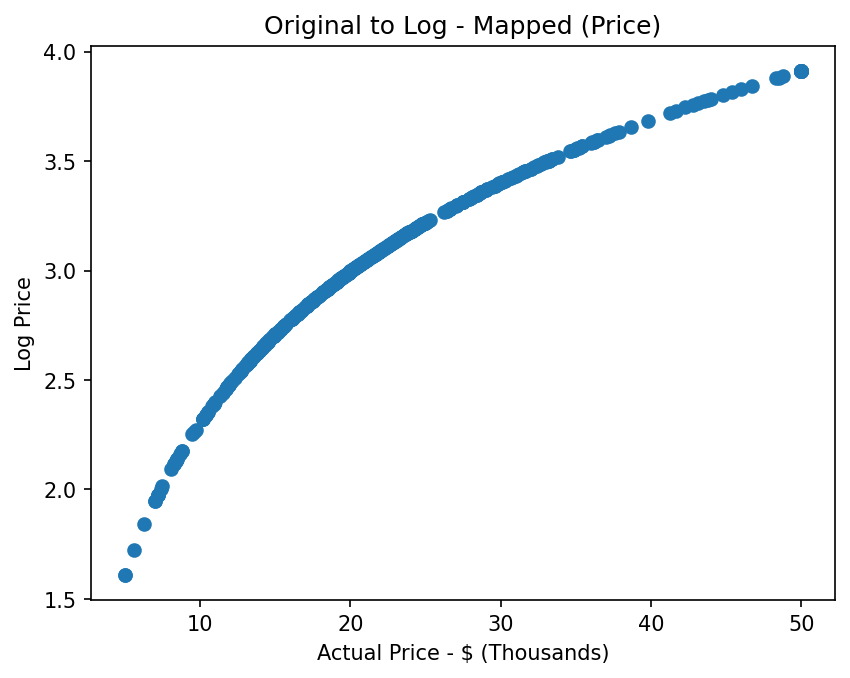

In [25]:
plt.figure(dpi = 150)

plt.scatter(data.PRICE, np.log(data.PRICE))
plt.title('Original to Log - Mapped (Price)')

plt.xlabel('Actual Price - $ (Thousands)')
plt.ylabel('Log Price')

plt.show()

## Regression - Log Prices

**Through the use of log prices, the model changes to:**

$$ \log (PR \hat ICE) = \theta _0 + \theta _1 RM + \theta _2 NOX + \theta_3 DIS + \theta _4 CHAS + ... + \theta _{13} LSTAT $$

In [26]:
updated_target = np.log(data['PRICE'])
features = data.drop('PRICE', axis = 1)

x_train, x_test, log_y_train, log_y_test = train_test_split(features, updated_target, test_size = 0.2, random_state = 10)

log_regr = LinearRegression()

log_regr.fit(x_train, log_y_train)
log_rsquared = log_regr.score(x_train, log_y_train)

log_predictions = log_regr.predict(x_train)
log_residuals = (log_y_train - log_predictions)

print(f'Training Data (r²) : {log_rsquared:.2}')

Training Data (r²) : 0.79


In [27]:
update_coeff = pd.DataFrame(data = log_regr.coef_, index = x_train.columns, columns = ['coef'])
update_coeff

,coef
CRIM,-0.01
ZN,0.00
INDUS,0.00
CHAS,0.08
NOX,-0.70
RM,0.07
AGE,0.00
DIS,-0.05
RAD,0.01
TAX,-0.00


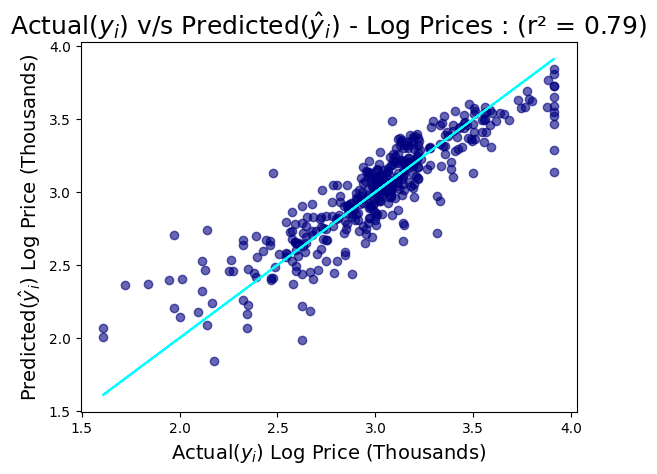

In [28]:
plt.figure(dpi = 100)
plt.scatter(x = log_y_train, y = log_predictions, c = 'navy', alpha = 0.6)
plt.plot(log_y_train, log_y_train, color = 'cyan')

plt.title(f'Actual($y _i$) v/s Predicted($\\hat y_i$) - Log Prices : (r² = {log_rsquared:.2})', fontsize = 18)
plt.xlabel(r'Actual($y _i$) Log Price (Thousands)', fontsize = 14)
plt.ylabel(r'Predicted($\hat y_i$) Log Price (Thousands)', fontsize = 14)

plt.show()

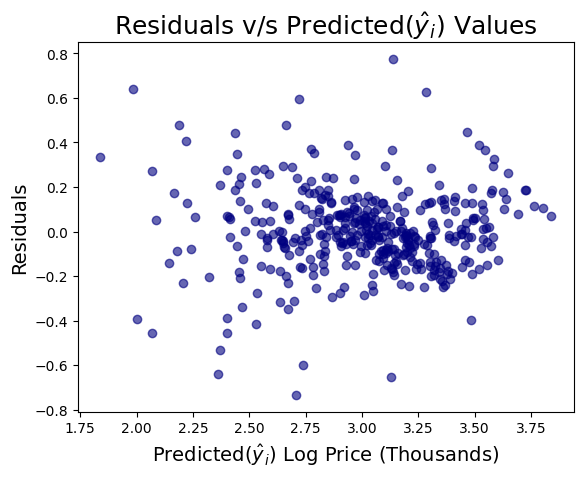

In [29]:
plt.figure(dpi = 100)
plt.scatter(x = log_predictions, y = log_residuals, c = 'navy', alpha = 0.6)

plt.title(r'Residuals v/s Predicted($\hat y_i$) Values', fontsize = 18)

plt.ylabel(r'Residuals', fontsize = 14)
plt.xlabel(r'Predicted($\hat y_i$) Log Price (Thousands)', fontsize = 14)

plt.show()

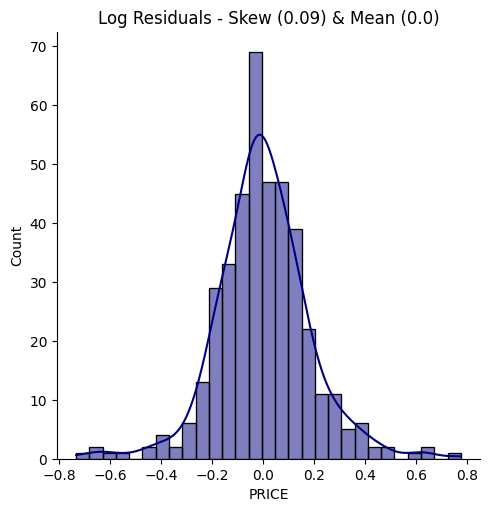

In [30]:
log_residual_mean = abs(round(log_residuals.mean(), 2))
log_residual_skew = round(log_residuals.skew(), 2)

sns.displot(log_residuals, kde = True, color = 'navy')
plt.title(f'Log Residuals - Skew ({log_residual_skew}) & Mean ({log_residual_mean})')

plt.show()

In [31]:
print(f'Initial Model Test Data (r²) : {regr.score(x_test, y_test):.2}')
print(f'Updated Model Test Data (r²) : {log_regr.score(x_test, log_y_test):.2}')

Initial Model Test Data (r²) : 0.67
Updated Model Test Data (r²) : 0.74


In [32]:
features = data.drop(['PRICE'], axis = 1)
average_vals = features.mean().values

property_stats = pd.DataFrame(data = average_vals.reshape(1, len(features.columns)), columns = features.columns)
property_stats

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65


In [33]:
estimate = log_regr.predict(property_stats)[0]
dollar_est = np.e ** estimate * 1000

print(f'Est. Property Valuation (ln) : ${estimate:.3}')
print(f'Est. Property Valuation : ${dollar_est:.6}')

Est. Property Valuation (ln) : $3.03
Est. Property Valuation : $20703.2


In [34]:
next_to_river = True
nr_rooms = 8
students_per_classroom = 20
distance_to_town = 5
pollution = data.NOX.quantile(q = 0.75)
amount_of_poverty = data.LSTAT.quantile(q = 0.25)

property_stats['RM'] = nr_rooms
property_stats['PTRATIO'] = students_per_classroom
property_stats['DIS'] = distance_to_town

if next_to_river:
    property_stats['CHAS'] = 1
else:
    property_stats['CHAS'] = 0

property_stats['NOX'] = pollution
property_stats['LSTAT'] = amount_of_poverty

estimate = log_regr.predict(property_stats)[0]
dollar_est = np.exp(estimate) * 1000

print(f'Est. Property Valuation (ln) : ${estimate:.3}')
print(f'Est. Property Valuation : ${dollar_est:.6}')

Est. Property Valuation (ln) : $3.25
Est. Property Valuation : $25792.0
